# 0. Import library

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


cuda is available


# 1-1. Import Train Data 

In [2]:
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')
print(df_all.shape)
print(df_all.columns)

nan_rows = df_all[df_all.isna().any(axis=1)]

df_all = df_all.dropna()

loc_X = df_all["X"].to_numpy().reshape(-1,1)
loc_Y = df_all["Y"].to_numpy().reshape(-1,1)
loc_Z = df_all["Z"].to_numpy().reshape(-1,1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
# dist_Z = df_all["Dist_to_nearest_Z"].to_numpy()[::2].reshape(-1,1)
scan_spd = df_all["scanning_speed"].to_numpy().reshape(-1,1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1,1)
laser_on_off = df_all["laser_power_number"].to_numpy().reshape(-1,1)

# apply moving average for mp temp
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1,1)

# apply moving average for mp depth
mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw,4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1,1)       


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


## 1-2. Normalize data

In [3]:
# stack input array
x_original_scale = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)
y_original_scale = np.concatenate((mp_temp, mp_depth), axis=1)

# scaling
x_max = np.max(x_original_scale,0).reshape(1,-1)
x_min = np.min(x_original_scale,0).reshape(1,-1) 
y_max = np.max(y_original_scale,0).reshape(1,-1) 
y_min = np.min(y_original_scale,0).reshape(1,-1)

print("x_max:", np.round(x_max, 3).tolist())
print("x_min:", np.round(x_min, 3).tolist())
print("y_max:", np.round(y_max, 3).tolist())
print("y_min:", np.round(y_min, 3).tolist())

x_max: [[7.5, 20.0, 20.0, 732.298]]
x_min: [[0.0, 0.75, 0.75, 504.26]]
y_max: [[4509.855, 0.551]]
y_min: [[436.608, -0.559]]


In [4]:
class scalers():
    def __init__(self,x_max, x_min, y_max, y_min) -> None:
        self.x_max = x_max
        self.x_min = x_min
        self.y_max = y_max
        self.y_min = y_min
        
        return None
    
    def scaler_x(self, x_original, dim_id = -1):
        if dim_id == -1:
            x_s = -1 + 2 * ((x_original - self.x_min) / (self.x_max-self.x_min))
            return x_s
        else: 
            x_s = -1 + 2 * (x_original - self.x_min[0,dim_id]) / (self.x_max[0,dim_id] - self.x_min[0,dim_id])
            return x_s
    
    def inv_scaler_x(self, x_s, dim_id = -1):
        
        if dim_id == -1:
            x_original = (x_s + 1)*0.5*(self.x_max-self.x_min) + self.x_min
            return x_original
        else: 
            x_original = (x_s + 1)*0.5*(self.x_max[0,dim_id] - self.x_min[0,dim_id]) + self.x_min[0,dim_id]
            return x_original
        
    def scaler_y(self, y_original):
        return -1 + 2 * ((y_original - self.y_min) / (self.y_max-self.y_min))
    
    def inv_scaler_y(self, y_s):
        return (y_s + 1)*0.5*(self.y_max-self.y_min) + self.y_min

In [5]:
scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original_scale)
y_s = scaler.scaler_y(y_original_scale)

print("x_s range:", np.min(x_s), "to", np.max(x_s))
print("y_s range:", np.min(y_s), "to", np.max(y_s))

print("x_s shape:", x_s.shape)
print("y_s shape:", y_s.shape)

x_s range: -1.0 to 1.0
y_s range: -1.0 to 1.0
x_s shape: (610417, 4)
y_s shape: (610417, 2)


## 1-3. Generate data

In [6]:
length = y_s.shape[0]

y_s_ref = np.random.uniform(0.0, 1.0, size=(length, 1))

e = 0.0001
y_depth_low = np.random.uniform(0.1423-e, 0.1423+e, size = (length,1))
y_depth_up = np.random.uniform(0.4126-e, 0.4126+e, size = (length,1))
# constraints!
#y_depth_low = 0*np.random.uniform(0.0, 0.5, size=(length, 1))
#y_depth_up = 0*np.random.uniform(0.5, 1.0, size=(length, 1))

y_s_const = np.concatenate((y_depth_low, y_depth_up), axis=1)

print("y_s_ref shape:", y_s_ref.shape)
print("y_s_const shape:", y_s_const.shape)

y_s_ref shape: (610417, 1)
y_s_const shape: (610417, 2)


## 1-4. Split data

In [7]:
# 기본 분할
cutoff_index = int(np.round(0.8 * x_s.shape[0]))
x_train, y_train = x_s[:cutoff_index], y_s[:cutoff_index]
x_val, y_val = x_s[cutoff_index:], y_s[cutoff_index:]
# y_ref_train, y_ref_val = y_s_ref[:cutoff_index], y_s_ref[cutoff_index:]
y_const_train, y_const_val = y_s_const[:cutoff_index], y_s_const[cutoff_index:]

window = 50
P = 50

# ------------------ Training set ------------------
n_train = cutoff_index - P - window
x_past_train = np.empty((n_train, window, 4))
y_past_train = np.empty((n_train, window, 2))
x_future_train = np.empty((n_train, P, 3))
y_ref_train_seq = np.empty((n_train, P, 1))
y_const_train_seq = np.empty((n_train, P, 2))

for i in tqdm(range(window, cutoff_index - P)):
    j = i - window
    x_past_train[j] = x_train[i-window:i]

    # shift for u past last component
    #u_last_shift = torch.empty(1).uniform_(-0.1, 0.1).item()
    #x_past_train[j, -1, 3] += u_last_shift

    y_past_train[j] = y_train[i-window:i]
    x_future_train[j] = x_train[i:i+P, :3]         

    # shift for temp future entire horizon
    # scalar_shift = torch.empty(1).uniform_(-0.1, 0.1).item()  # Random scalar shift for y_ref
    # y_ref_train_seq[j] = y_train[i:i+P, :1] + scalar_shift
    # y_ref_train_seq[j] = y_ref_train[i:i+P]

    # 조건에 따라 다른 범위의 shift 적용(0801)
    if y_train[i, 0].item() < 0.3:
        scalar_shift = torch.empty(1).uniform_(-0.0001, 0.0001).item()
    else:
        scalar_shift = torch.empty(1).uniform_(-0.0001, 0.0001).item()

    y_ref_train_seq[j] = y_train[i:i+P, :1] + scalar_shift

    y_const_train_seq[j] = y_const_train[i:i+P]

# ------------------ Validation set ------------------
val_cutoff = x_s.shape[0] - cutoff_index
n_val = val_cutoff - P - window
x_past_val = np.empty((n_val, window, 4))
y_past_val = np.empty((n_val, window, 2))
x_future_val = np.empty((n_val, P, 3))
y_ref_val_seq = np.empty((n_val, P, 1))
y_const_val_seq = np.empty((n_val, P, 2))

for i in tqdm(range(window, val_cutoff - P)):
    j = i - window
    x_past_val[j] = x_val[i-window:i]
    y_past_val[j] = y_val[i-window:i]
    x_future_val[j] = x_val[i:i+P, :3]

    # scalar_shift = torch.empty(1).uniform_(-0.1, 0.1).item() 
    # y_ref_val_seq[j] = y_val[i:i+P, :1] + scalar_shift
    # y_ref_val_seq[j] = y_ref_val[i:i+P]

    # 조건에 따라 다른 범위의 shift 적용 (0801)
    if y_val[i, 0].item() < 0.3:
        scalar_shift = torch.empty(1).uniform_(-0.0001, 0.0001).item()
    else:
        scalar_shift = torch.empty(1).uniform_(-0.1, 0.1).item()
    y_ref_val_seq[j] = y_val[i:i+P, :1] + scalar_shift


    y_const_val_seq[j] = y_const_val[i:i+P]

x_past_train = torch.tensor(x_past_train, dtype=torch.float32)
y_past_train = torch.tensor(y_past_train, dtype=torch.float32)
x_future_train = torch.tensor(x_future_train, dtype=torch.float32)
y_ref_train_seq = torch.tensor(y_ref_train_seq, dtype=torch.float32)
y_const_train_seq = torch.tensor(y_const_train_seq, dtype=torch.float32)

print("x_past shape : ", x_past_train.shape)       # (n_train, 50, 4)
print("y_past shape : ",y_past_train.shape)       # (n_train, 50, 2)
print("x_future shape : ",x_future_train.shape)     # (n_train, 50, 3)
print("y_ref shape : ",y_ref_train_seq.shape)    # (n_train, 50, 1)
print("y_const shape : ",y_const_train_seq.shape)  # (n_train, 50, 2)

x_past_val = torch.tensor(x_past_val, dtype=torch.float32)
y_past_val = torch.tensor(y_past_val, dtype=torch.float32)
x_future_val = torch.tensor(x_future_val, dtype=torch.float32)
y_ref_val_seq = torch.tensor(y_ref_val_seq, dtype=torch.float32)
y_const_val_seq = torch.tensor(y_const_val_seq, dtype=torch.float32)

print("x_past_val shape : ", x_past_val.shape)       # (n_val, 50, 4)
print("y_past_val shape : ", y_past_val.shape)       # (n_val, 50, 2)
print("x_future_val shape : ", x_future_val.shape)   # (n_val, 50, 3)
print("y_ref_val shape : ", y_ref_val_seq.shape)     # (n_val, 50, 1)
print("y_const_val shape : ", y_const_val_seq.shape) # (n_val, 50, 2)

100%|██████████| 121983/121983 [00:01<00:00, 96622.35it/s] 


x_past shape :  torch.Size([488234, 50, 4])
y_past shape :  torch.Size([488234, 50, 2])
x_future shape :  torch.Size([488234, 50, 3])
y_ref shape :  torch.Size([488234, 50, 1])
y_const shape :  torch.Size([488234, 50, 2])
x_past_val shape :  torch.Size([121983, 50, 4])
y_past_val shape :  torch.Size([121983, 50, 2])
x_future_val shape :  torch.Size([121983, 50, 3])
y_ref_val shape :  torch.Size([121983, 50, 1])
y_const_val shape :  torch.Size([121983, 50, 2])


# 5. Import Sampled Data

In [8]:
import os
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import copy


def make_case_dataset(
    case_id,
    scaler,
    base_dir="/home/ftk3187/github/DPC_research/02_DED/4_policy_0725",
    window=50,
    P=50,
    e=1e-4,
    ctrl_col_idx=0,
    temp_col_idx=0,
    depth_col_idx=1
):
    # -----------------------------
    # ① 파일 경로 설정
    # -----------------------------
    ctrl_path   = os.path.join(base_dir, f"simulation_outputs_case2/u_outputs_laser_{case_id}.csv")
    output_path = os.path.join(base_dir, f"simulation_outputs_case2/x_outputs_laser_{case_id}.csv")
    ref_path    = os.path.join(base_dir, f"split_by_laser_power_number/laser_power_number_{case_id}.csv")

    # -----------------------------
    # ② 파일 로드 및 길이 정합
    # -----------------------------
    df_ref  = pd.read_csv(ref_path).dropna()
    df_ctrl = pd.read_csv(ctrl_path, header=None).dropna()
    df_out  = pd.read_csv(output_path, header=None).dropna()
    length = min(len(df_ref), len(df_ctrl), len(df_out))
    if length < (window + P + 1):
        raise ValueError(f"[Case {case_id}] length too short: {length} < window+P+1 ({window+P+1})")

    # -----------------------------
    # ③ 입력 feature 구성
    # -----------------------------
    loc_Z  = df_ref["Z"].to_numpy()[:length].reshape(-1, 1)
    dist_X = df_ref["Dist_to_nearest_X"].to_numpy()[:length].reshape(-1, 1)
    dist_Y = df_ref["Dist_to_nearest_Y"].to_numpy()[:length].reshape(-1, 1)

    if ctrl_col_idx >= df_ctrl.shape[1]:
        raise IndexError(f"[Case {case_id}] ctrl_col_idx={ctrl_col_idx} out of range for u_outputs with shape {df_ctrl.shape}")
    ctrl = df_ctrl.iloc[:length, ctrl_col_idx].to_numpy().reshape(-1, 1)

    # -----------------------------
    # ④ 출력 feature 구성 (moving avg 적용)
    # -----------------------------
    if max(temp_col_idx, depth_col_idx) >= df_out.shape[1]:
        raise IndexError(f"[Case {case_id}] (temp_col_idx, depth_col_idx)=({temp_col_idx},{depth_col_idx}) out of range for x_outputs with shape {df_out.shape}")
    mp_temp_raw  = df_out.iloc[:length, temp_col_idx].to_numpy().reshape(-1)
    mp_depth_raw = df_out.iloc[:length, depth_col_idx].to_numpy().reshape(-1)

    mp_temp  = copy.deepcopy(mp_temp_raw)
    mp_depth = copy.deepcopy(mp_depth_raw)
    mp_temp[1:-2]  = moving_average_1d(mp_temp_raw,  4)
    mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
    mp_temp  = mp_temp.reshape(-1, 1)
    mp_depth = mp_depth.reshape(-1, 1)

    # -----------------------------
    # ⑤ 정규화 (ref에도 moving avg 적용)
    # -----------------------------
    x_original = np.concatenate([loc_Z, dist_X, dist_Y, ctrl], axis=1)
    y_original = np.concatenate([mp_temp, mp_depth], axis=1)
    x_s = scaler.scaler_x(x_original)
    y_s = scaler.scaler_y(y_original)

    if "melt_pool_temperature" not in df_ref.columns:
        raise KeyError(f"[Case {case_id}] 'melt_pool_temperature' column not found in {ref_path}")
    
    # --- 🔧 여기 추가: reference 온도도 smoothing ---
    mp_temp_ref_raw = df_ref["melt_pool_temperature"].to_numpy()[:length].reshape(-1)
    mp_temp_ref = copy.deepcopy(mp_temp_ref_raw)
    mp_temp_ref[1:-2] = moving_average_1d(mp_temp_ref_raw, 4)
    mp_temp_ref = mp_temp_ref.reshape(-1, 1)
    
    # --- 정규화 ---
    y_s_ref = scaler.scaler_y(mp_temp_ref)


    # -----------------------------
    # ⑥ 슬라이딩 윈도우 구성
    # -----------------------------
    n_samples = length - window - P
    x_past      = np.empty((n_samples, window, 4), dtype=np.float32)
    y_past      = np.empty((n_samples, window, 2), dtype=np.float32)
    x_future    = np.empty((n_samples, P, 3), dtype=np.float32)
    y_ref_seq   = np.empty((n_samples, P, 1), dtype=np.float32)
    y_const_seq = np.empty((n_samples, P, 2), dtype=np.float32)

    for i in tqdm(range(window, length - P), desc=f"Case {case_id} sliding window"):
        j = i - window
        x_past[j]      = x_s[i-window:i]            # 과거 입력 (Z, X, Y, ctrl)
        y_past[j]      = y_s[i-window:i]            # 과거 출력 (temp, depth)
        x_future[j]    = x_s[i:i+P, :3]             # 미래 입력 (Z, X, Y)
        y_ref_seq[j]   = y_s_ref[i:i+P,0].reshape(-1, 1)  # reference temp
        y_const_seq[j] = y_s_const[i:i+P]           # depth 상/하한

    # -----------------------------
    # ⑦ Torch tensor 변환
    # -----------------------------
    x_past      = torch.from_numpy(x_past)
    y_past      = torch.from_numpy(y_past)
    x_future    = torch.from_numpy(x_future)
    y_ref_seq   = torch.from_numpy(y_ref_seq)
    y_const_seq = torch.from_numpy(y_const_seq)

    # -----------------------------
    # ⑧ 출력 로그
    # ----------------------------

    return x_past, y_past, x_future, y_ref_seq, y_const_seq


# 6. Data into format

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sequence_vae import SequenceVAE

# ===============================
# 1️⃣ 학습된 VAE 불러오기
# ===============================
vae = SequenceVAE(
    input_dim=12,
    hidden_dim=128,
    latent_dim=16,
    num_layers=2
)
checkpoint_path = "/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/checkpoints/vae_128H_16Z_epoch30_case0.pth"
vae.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
device = "cuda" if torch.cuda.is_available() else "cpu"
vae = vae.to(device)
vae.eval()
print("✅ Loaded:", checkpoint_path)


# ===============================
# 2️⃣ 여러 case 데이터 결합
# ===============================
def make_multi_case_dataset(case_ids, scaler, **kwargs):
    x_past_all, y_past_all, x_future_all, y_ref_all, y_const_all = [], [], [], [], []
    for cid in case_ids:
        try:
            x_past, y_past, x_future, y_ref, y_const = make_case_dataset(
                case_id=cid, scaler=scaler, **kwargs
            )
            x_past_all.append(x_past)
            y_past_all.append(y_past)
            x_future_all.append(x_future)
            y_ref_all.append(y_ref)
            y_const_all.append(y_const)
            print(f"[+] Case {cid} loaded: {x_past.shape[0]} samples")
        except Exception as e:
            print(f"[!] Case {cid} skipped due to error: {e}")

    # 결합
    return (
        torch.cat(x_past_all, dim=0),
        torch.cat(y_past_all, dim=0),
        torch.cat(x_future_all, dim=0),
        torch.cat(y_ref_all, dim=0),
        torch.cat(y_const_all, dim=0)
    )


# ✅ 여러 case 데이터 로드
case_list = range(2, 30)  # 필요에 따라 2~99로 변경 가능
x_past_all, y_past_all, x_future_all, y_ref_all, y_const_all = make_multi_case_dataset(
    case_ids=case_list,
    scaler=scaler,
    base_dir="/home/ftk3187/github/DPC_research/02_DED/4_policy_0725",
    window=50,
    P=50,
    ctrl_col_idx=0,
    temp_col_idx=0,
    depth_col_idx=1
)

print("\n✅ 전체 case 결합 완료:")
print("x_past_all :", x_past_all.shape)
print("y_past_all :", y_past_all.shape)


# ===============================
# 3️⃣ 입력 결합 (train / case)
# ===============================
def combine_inputs(x_past, y_past, x_future, y_ref, y_const):
    return torch.cat([x_past, y_past, x_future, y_ref, y_const], dim=-1)

X_train = combine_inputs(x_past_train, y_past_train, x_future_train, y_ref_train_seq, y_const_train_seq)
X_case_all = combine_inputs(x_past_all, y_past_all, x_future_all, y_ref_all, y_const_all)

print("X_train:", X_train.shape)
print("X_case_all:", X_case_all.shape)


# ===============================
# 4️⃣ Latent 벡터 배치 단위 인코딩
# ===============================
def encode_in_batches(model, X, batch_size=512):
    zs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            batch = X[i:i+batch_size].to(device)
            mu, _ = model.encoder(batch)
            zs.append(mu.cpu())
            del batch, mu
            torch.cuda.empty_cache()
    return torch.cat(zs, dim=0)

z_train = encode_in_batches(vae, X_train, batch_size=512).numpy()
z_case_all = encode_in_batches(vae, X_case_all, batch_size=512).numpy()
print("✅ Latent extracted:", z_train.shape, z_case_all.shape)


✅ Loaded: /home/ftk3187/github/DPC_research/02_DED/4_policy_0725/checkpoints/vae_128H_16Z_epoch30_case0.pth
[!] Case 2 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_2.csv'
[!] Case 3 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_3.csv'
[!] Case 4 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_4.csv'
[!] Case 5 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_5.csv'
[!] Case 6 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_6.csv'
[!] Case 7 skipped due

Case 15 sliding window: 100%|██████████| 1951/1951 [00:00<00:00, 204199.41it/s]


[+] Case 15 loaded: 1951 samples


Case 16 sliding window: 100%|██████████| 1951/1951 [00:00<00:00, 206003.75it/s]


[+] Case 16 loaded: 1951 samples


Case 17 sliding window: 100%|██████████| 1951/1951 [00:00<00:00, 203691.12it/s]


[+] Case 17 loaded: 1951 samples


Case 18 sliding window: 100%|██████████| 1951/1951 [00:00<00:00, 202311.29it/s]

[+] Case 18 loaded: 1951 samples
[!] Case 19 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_19.csv'
[!] Case 20 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_20.csv'
[!] Case 21 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_21.csv'
[!] Case 22 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_22.csv'
[!] Case 23 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_23.csv'
[!] Case 24 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/g

[!] Case 26 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_26.csv'
[!] Case 27 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_27.csv'
[!] Case 28 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_28.csv'
[!] Case 29 skipped due to error: [Errno 2] No such file or directory: '/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/simulation_outputs_case2/u_outputs_laser_29.csv'

✅ 전체 case 결합 완료:
x_past_all : torch.Size([7804, 50, 4])
y_past_all : torch.Size([7804, 50, 2])
X_train: torch.Size([488234, 50, 12])
X_case_all: torch.Size([7804, 50, 12])
✅ Latent extracted: (488234, 16) (7804, 16)


# 7. VAE Model Load

In [10]:
# ---------------------------
# 1️⃣ 설정 및 모델 로드
# ---------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
input_dim = X_train.shape[-1]  # 12
latent_dim = 16

# 모델 구조 동일하게 생성 후 weight 로드
model_path = "/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/checkpoints/vae_128H_16Z_epoch20.pth"
vae = SequenceVAE(input_dim=input_dim, hidden_dim=128, latent_dim=latent_dim, num_layers=2).to(device)
vae.load_state_dict(torch.load(model_path, map_location=device))
vae.eval()
print(f"✅ 모델 로드 완료: {model_path}")


✅ 모델 로드 완료: /home/ftk3187/github/DPC_research/02_DED/4_policy_0725/checkpoints/vae_128H_16Z_epoch20.pth


# 8(1). Reconstraction Sample test

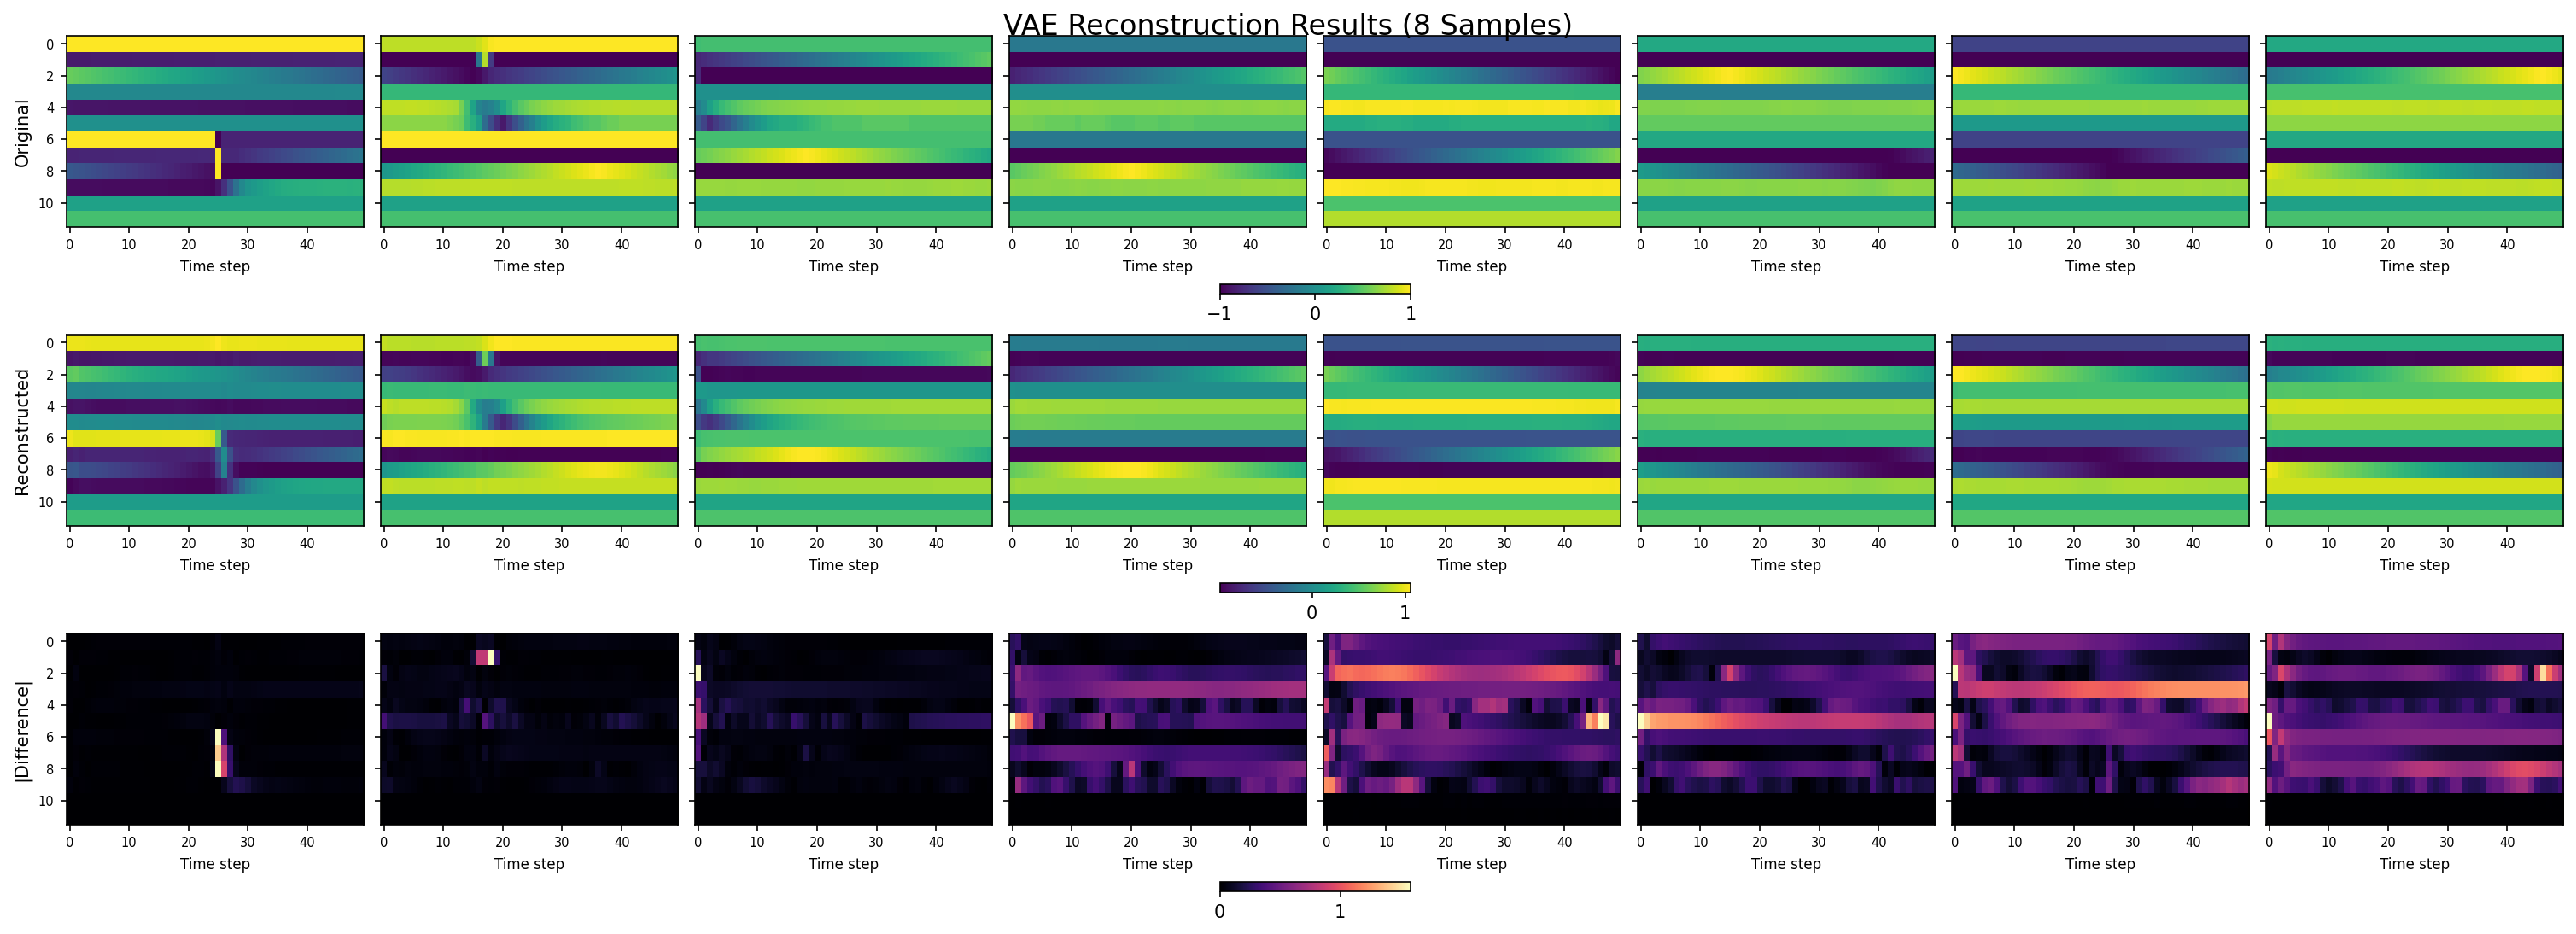

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

n_samples = 8
indices = np.random.choice(X_train.shape[0], n_samples, replace=False)
X_sample = X_train[indices].to(device)

with torch.no_grad():
    mu, logvar = vae.encoder(X_sample)
    z = vae.reparameterize(mu, logvar)
    X_recon = vae.decoder(z)

X_sample = X_sample.cpu().numpy()
X_recon = X_recon.cpu().numpy()

# ---------------------------------------
# 2행 × 4열, 각 샘플마다 3개 이미지를 세로로 나열 (Original, Recon, Diff)
# ---------------------------------------
fig, axes = plt.subplots(3, n_samples, figsize=(2.5*n_samples, 7), constrained_layout=True, dpi=150)

titles = ["Original", "Reconstructed", "|Difference|"]

for j in range(n_samples):
    diff = np.abs(X_sample[j] - X_recon[j])
    for i, data in enumerate([X_sample[j], X_recon[j], diff]):
        im = axes[i, j].imshow(data.T, aspect='auto', cmap='magma' if i==2 else 'viridis',
                               interpolation='nearest')
        if j == 0:
            axes[i, j].set_ylabel(titles[i], fontsize=10)
        else:
            axes[i, j].set_yticklabels([])
        axes[i, j].set_xlabel("Time step", fontsize=8)
        axes[i, j].tick_params(labelsize=7)

# 컬러바는 각 행마다 하나씩
for i in range(3):
    fig.colorbar(axes[i, 0].images[0], ax=axes[i, :], orientation='horizontal', fraction=0.05, pad=0.05)

fig.suptitle("VAE Reconstruction Results (8 Samples)", fontsize=16, y=1.02)
plt.show()


# 8(2). Reconstruction Error (Average)

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def analyze_reconstruction(X_data, vae, device, n_samples=20000, title_prefix=""):
    """주어진 데이터셋에서 reconstruction error 계산 및 통계 반환"""
    n_samples = min(n_samples, X_data.shape[0])
    indices = np.random.choice(X_data.shape[0], n_samples, replace=False)
    X_sample = X_data[indices].to(device)

    with torch.no_grad():
        mu, logvar = vae.encoder(X_sample)
        z = vae.reparameterize(mu, logvar)
        X_recon = vae.decoder(z)

    X_sample = X_sample.cpu().numpy()
    X_recon = X_recon.cpu().numpy()

    # Reconstruction difference (MAE)
    diff = np.abs(X_sample - X_recon)  # [N, T, F]
    diff_mean = diff.mean(axis=(0, 1))  # feature별 평균 오차
    diff_time_mean = diff.mean(axis=0).T  # feature × time 평균 오차 (sample 평균)

    print(f"\n📊 {title_prefix} Feature-wise mean reconstruction error:")
    for i, val in enumerate(diff_mean):
        print(f"  Feature {i+1:2d}: {val:.6f}")

    return diff_mean, diff_time_mean


# ---------------------------
# 1️⃣ 두 데이터셋 비교
# ---------------------------
diff_mean_train, diff_time_train = analyze_reconstruction(X_train, vae, device, title_prefix="TRAIN")
diff_mean_case,  diff_time_case  = analyze_reconstruction(X_case_all, vae, device, title_prefix="CASE")


# ---------------------------
# 2️⃣ 시각화 (2행 × 2열)
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)
plt.subplots_adjust(hspace=0.4)

# (1) TRAIN - barplot
axes[0, 0].bar(np.arange(len(diff_mean_train)), diff_mean_train, color="C1", alpha=0.8)
axes[0, 0].set_title("TRAIN: Average Reconstruction Error (MAE)")
axes[0, 0].set_xlabel("Feature index")
axes[0, 0].set_ylabel("Mean |X - X_recon|")
axes[0, 0].grid(alpha=0.3)

# (2) TRAIN - heatmap
im1 = axes[0, 1].imshow(diff_time_train, aspect="auto", cmap="magma")
axes[0, 1].set_title("TRAIN: Feature-wise Error over Time")
axes[0, 1].set_xlabel("Time step")
axes[0, 1].set_ylabel("Feature index")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# (3) CASE - barplot
axes[1, 0].bar(np.arange(len(diff_mean_case)), diff_mean_case, color="C0", alpha=0.8)
axes[1, 0].set_title("CASE: Average Reconstruction Error (MAE)")
axes[1, 0].set_xlabel("Feature index")
axes[1, 0].set_ylabel("Mean |X - X_recon|")
axes[1, 0].grid(alpha=0.3)

# (4) CASE - heatmap
im2 = axes[1, 1].imshow(diff_time_case, aspect="auto", cmap="magma")
axes[1, 1].set_title("CASE: Feature-wise Error over Time")
axes[1, 1].set_xlabel("Time step")
axes[1, 1].set_ylabel("Feature index")
fig.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

fig.suptitle("VAE Reconstruction Error Comparison (TRAIN vs CASE)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


OutOfMemoryError: CUDA out of memory. Tried to allocate 10.21 GiB. GPU 0 has a total capacity of 47.54 GiB of which 922.19 MiB is free. Process 768816 has 262.00 MiB memory in use. Process 1765032 has 1.40 GiB memory in use. Process 1784920 has 306.00 MiB memory in use. Process 1767873 has 21.84 GiB memory in use. Process 1875713 has 21.84 GiB memory in use. Including non-PyTorch memory, this process has 1002.00 MiB memory in use. Of the allocated memory 670.39 MiB is allocated by PyTorch, and 15.61 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# 8(2). UMAP (X_TRAIN/ X_RUN)

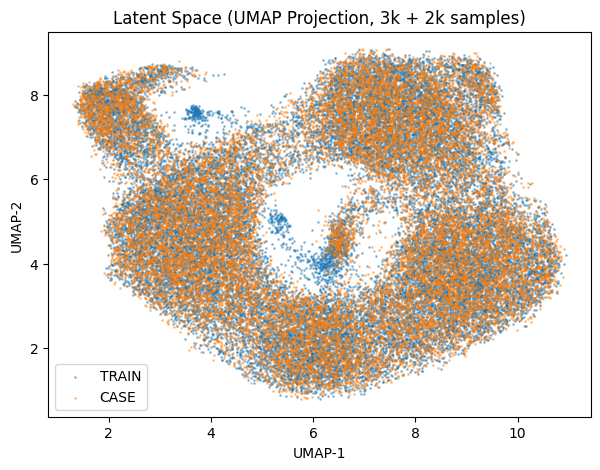

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap

def get_latent(X_data, vae, device, batch_size=256):
    vae.eval()
    z_list = []
    with torch.no_grad():
        for i in range(0, X_data.shape[0], batch_size):
            batch = X_data[i:i+batch_size].to(device)
            mu, logvar = vae.encoder(batch)
            z = vae.reparameterize(mu, logvar)
            z_list.append(z.cpu())
    return torch.cat(z_list, dim=0).numpy()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- sample subset to keep UMAP fast ---
n_train, n_case = 30000, 20000
idx_train = np.random.choice(X_train.shape[0], n_train, replace=False)
idx_case  = np.random.choice(X_case_all.shape[0], n_case, replace=False)
X_train_sub, X_case_sub = X_train[idx_train], X_case_all[idx_case]

# --- latent extraction ---
Z_train = get_latent(X_train_sub, vae, device)
Z_case  = get_latent(X_case_sub,  vae, device)

# --- combine and label ---
Z_all = np.concatenate([Z_train, Z_case])
labels = np.array(['TRAIN']*len(Z_train) + ['CASE']*len(Z_case))

# --- UMAP projection ---
reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.2,
    metric='euclidean',
    random_state=42
)
Z_2d = reducer.fit_transform(Z_all)

# --- plot ---
plt.figure(figsize=(7,5))
plt.scatter(Z_2d[labels=="TRAIN",0], Z_2d[labels=="TRAIN",1], s=1, alpha=0.4, label='TRAIN')
plt.scatter(Z_2d[labels=="CASE",0],  Z_2d[labels=="CASE",1],  s=1, alpha=0.4, label='CASE')
plt.legend()
plt.title("Latent Space (UMAP Projection, 3k + 2k samples)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()



# 8(3). KNN, PCA (X_TRAIN/ X_RUN)

Uncovered fraction: 0.05


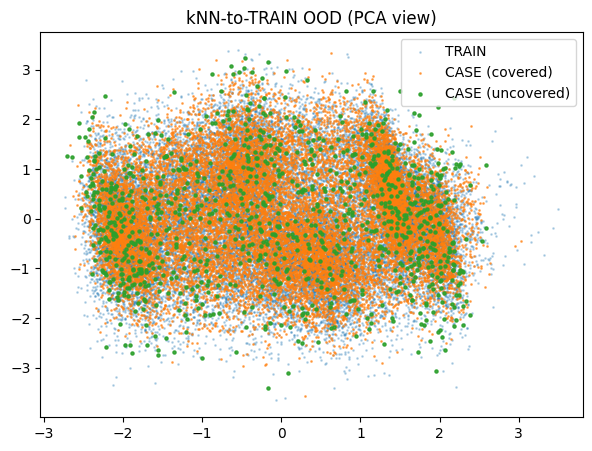

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
Z_tr = get_latent(X_train_sub, vae, device)
Z_cs = get_latent(X_case_sub,  vae, device)

nbrs = NearestNeighbors(n_neighbors=10, algorithm='auto', metric='euclidean').fit(Z_tr)
dists, _ = nbrs.kneighbors(Z_cs)                 # shape: [n_case, k]
score = dists.mean(axis=1)                       # OOD score
thr = np.percentile(score, 95)                   # top-5% as uncovered

mask = score >= thr
print("Uncovered fraction:", mask.mean())

# visualize with PCA for speed
from sklearn.decomposition import PCA
P = PCA(n_components=2).fit(np.vstack([Z_tr, Z_cs]))
Ztr_2d = P.transform(Z_tr)
Zcs_2d = P.transform(Z_cs)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(Ztr_2d[:,0], Ztr_2d[:,1], s=1, alpha=0.25, label='TRAIN')
plt.scatter(Zcs_2d[~mask,0], Zcs_2d[~mask,1], s=1, alpha=0.6, label='CASE (covered)')
plt.scatter(Zcs_2d[mask,0],  Zcs_2d[mask,1],  s=5, alpha=0.9, label='CASE (uncovered)')
plt.legend(); plt.title("kNN-to-TRAIN OOD (PCA view)"); plt.show()


# 8(4). Uncovered Sampling

Using device: cuda
Extracting latent spaces...
Latent shapes -> TRAIN: (488234, 16), CASE: (24572, 16)
Computing distance from CASE to TRAIN manifold...

📊 Distance statistics (CASE → TRAIN latent manifold)
Total CASE samples       : 24572
Mean distance (all CASE) : 1.9843
Std  distance (all CASE) : 0.2932
Top 5.0% mean distance : 2.7074
95th percentile threshold: 2.5264
Min / Max distance       : 1.2806 / 3.9417


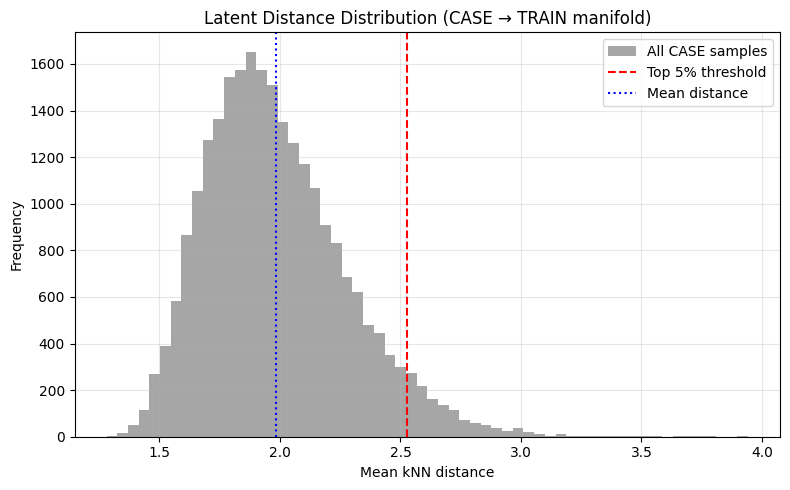

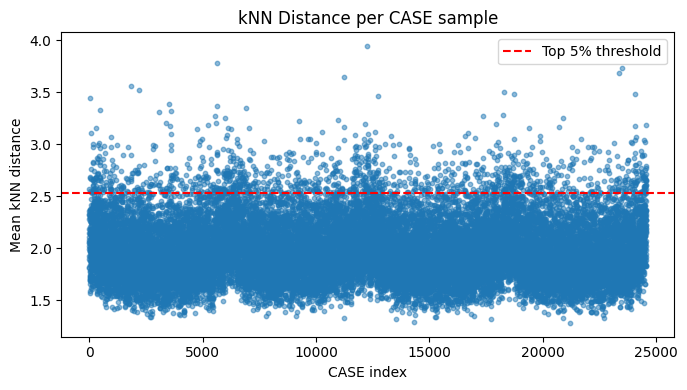

✅ Selected 1229 uncovered samples (5.0% of CASE)

Reconstructing uncovered CASE samples...
✅ Saved reconstructed samples to: vae_recon_uncovered_case1.csv
DataFrame shape: (1229, 1201)
Included original case indices in 'case_index' column.


In [ ]:
import torch
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# =========================================================
# 1️⃣ latent 추출 함수
# =========================================================
def get_latent(X_data, vae, device, batch_size=256):
    """Compute latent vectors from VAE encoder"""
    vae.eval()
    z_list = []
    with torch.no_grad():
        for i in range(0, X_data.shape[0], batch_size):
            batch = X_data[i:i+batch_size].to(device)
            mu, logvar = vae.encoder(batch)
            z = vae.reparameterize(mu, logvar)
            z_list.append(z.cpu())
    return torch.cat(z_list, dim=0).numpy()

# =========================================================
# 2️⃣ uncovered CASE 샘플 선택 + 거리 분석 시각화 함수
# =========================================================
def find_uncovered_cases(X_train, X_case_all, vae, device, ratio=0.05, k=10):
    """Find CASE samples far from TRAIN latent manifold and visualize distances"""
    print("Extracting latent spaces...")
    Z_train = get_latent(X_train, vae, device)
    Z_case  = get_latent(X_case_all, vae, device)
    print(f"Latent shapes -> TRAIN: {Z_train.shape}, CASE: {Z_case.shape}")

    # Compute kNN distance
    print("Computing distance from CASE to TRAIN manifold...")
    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(Z_train)
    dists, _ = nbrs.kneighbors(Z_case)
    scores = dists.mean(axis=1)  # mean kNN distance per CASE

    # Select top X% CASE samples as uncovered
    threshold = np.percentile(scores, 100*(1 - ratio))
    idx_uncovered = np.where(scores > threshold)[0]
    X_case_uncovered = X_case_all[idx_uncovered]

    # --- 통계 요약 ---
    print("\n📊 Distance statistics (CASE → TRAIN latent manifold)")
    print(f"Total CASE samples       : {len(scores)}")
    print(f"Mean distance (all CASE) : {scores.mean():.4f}")
    print(f"Std  distance (all CASE) : {scores.std():.4f}")
    print(f"Top {ratio*100:.1f}% mean distance : {scores[idx_uncovered].mean():.4f}")
    print(f"95th percentile threshold: {threshold:.4f}")
    print(f"Min / Max distance       : {scores.min():.4f} / {scores.max():.4f}")

    # --- 시각화 ---
    plt.figure(figsize=(8,5))
    plt.hist(scores, bins=60, color='gray', alpha=0.7, label='All CASE samples')
    plt.axvline(threshold, color='red', linestyle='--', label=f"Top {ratio*100:.0f}% threshold")
    plt.axvline(scores.mean(), color='blue', linestyle=':', label="Mean distance")
    plt.title("Latent Distance Distribution (CASE → TRAIN manifold)")
    plt.xlabel("Mean kNN distance")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Distance Scatter Plot (optional: visualization of latent space distances) ---
    plt.figure(figsize=(7,4))
    plt.scatter(range(len(scores)), scores, s=10, alpha=0.5, c='tab:blue')
    plt.axhline(threshold, color='red', linestyle='--', label=f"Top {ratio*100:.0f}% threshold")
    plt.title("kNN Distance per CASE sample")
    plt.xlabel("CASE index")
    plt.ylabel("Mean kNN distance")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"✅ Selected {len(idx_uncovered)} uncovered samples ({ratio*100:.1f}% of CASE)")
    return X_case_uncovered, idx_uncovered, scores, threshold

# =========================================================
# 3️⃣ uncovered CASE reconstruction & CSV 저장 함수
# =========================================================
def reconstruct_and_save(X_case_uncovered, vae, device, idx_uncovered, save_path="vae_recon_uncovered_case0.csv"):
    """Reconstruct uncovered samples using VAE and save to CSV (with original indices)"""
    vae = vae.to(device)
    vae.eval()
    X_case_uncovered = X_case_uncovered.to(device)

    print("\nReconstructing uncovered CASE samples...")
    with torch.no_grad():
        mu, logvar = vae.encoder(X_case_uncovered)
        z = vae.reparameterize(mu, logvar)
        X_recon = vae.decoder(z)

    # move to CPU
    X_case_uncovered_np = X_case_uncovered.cpu().numpy()
    X_recon_np = X_recon.cpu().numpy()

    # flatten for CSV
    n, t, f = X_recon_np.shape
    X_orig_flat = X_case_uncovered_np.reshape(n, -1)
    X_recon_flat = X_recon_np.reshape(n, -1)

    cols_orig  = [f"orig_t{ti}_f{fi}"  for ti in range(t) for fi in range(f)]
    cols_recon = [f"recon_t{ti}_f{fi}" for ti in range(t) for fi in range(f)]

    df = pd.DataFrame(np.hstack([X_orig_flat, X_recon_flat]),
                      columns=cols_orig + cols_recon)

    # ✅ add original indices for traceability
    df.insert(0, "case_index", idx_uncovered)

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    df.to_csv(save_path, index=False)

    print(f"✅ Saved reconstructed samples to: {save_path}")
    print(f"DataFrame shape: {df.shape}")
    print(f"Included original case indices in 'case_index' column.")
    return df

# =========================================================
# 4️⃣ 실행 예시
# =========================================================
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    # --- uncovered CASE 추출 + 거리분석 ---
    X_case_uncovered, idx_uncovered, scores, threshold = find_uncovered_cases(
        X_train, X_case_all, vae, device, ratio=0.05, k=10
    )
    # --- reconstruction 및 저장 ---
    df_recon = reconstruct_and_save(X_case_uncovered, vae, device, idx_uncovered, "vae_recon_uncovered_case0.csv")



Loaded reconstruction matrix: (1229, 600)
Reshaped to 3D tensor: (1229, 50, 12)  (n, T, F)
Randomly selected 1000 samples from total 1229


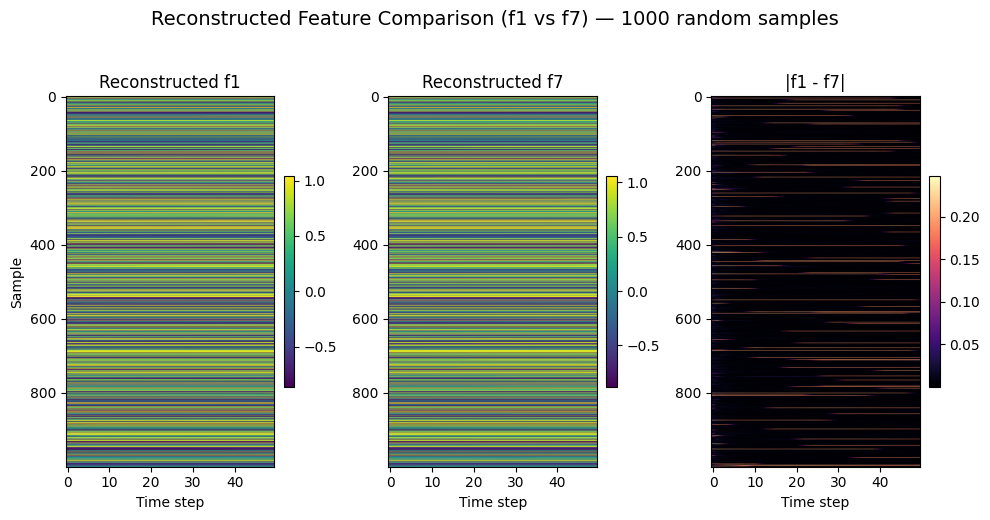

Applied clipping for (f5, f10): max limited to 0.071


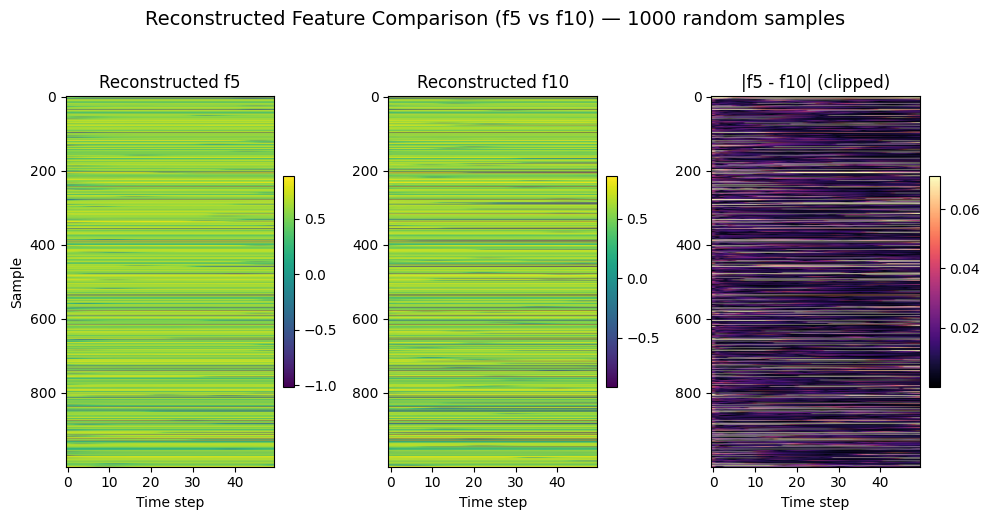

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1️⃣ CSV 불러오기
# =========================================================
csv_path = "vae_recon_uncovered_case0.csv"
df = pd.read_csv(csv_path)

# reconstruction 데이터만 선택
recon_cols = [c for c in df.columns if c.startswith("recon_")]
X_recon_flat = df[recon_cols].values
N_total, TF = X_recon_flat.shape
print(f"Loaded reconstruction matrix: {X_recon_flat.shape}")

# =========================================================
# 2️⃣ 원래 shape 복원 (예: T=50, F=12)
# =========================================================
F = 12
T = TF // F
X_recon = X_recon_flat.reshape(-1, T, F)
print(f"Reshaped to 3D tensor: {X_recon.shape}  (n, T, F)")

# =========================================================
# 3️⃣ 무작위 샘플링
# =========================================================
n_samples = min(1000, X_recon.shape[0])
indices = np.random.choice(X_recon.shape[0], n_samples, replace=False)
print(f"Randomly selected {n_samples} samples from total {X_recon.shape[0]}")

# 비교할 feature 쌍
features_pairs = [(0, 6), (4, 9)]  # (f1,f7), (f5,f10)

# =========================================================
# 4️⃣ 시각화 루프
# =========================================================
for f_a, f_b in features_pairs:
    fA_vals = X_recon[indices, :, f_a]
    fB_vals = X_recon[indices, :, f_b]
    diff_vals = np.abs(fA_vals - fB_vals)

    # ✳️ f5–f10쌍만 클리핑 (튀는 값 제거)
    if (f_a, f_b) == (4, 9):
        # 예: 상위 1% 이상값을 잘라내기
        upper_clip = np.percentile(diff_vals, 90)
        diff_vals = np.clip(diff_vals, 0, upper_clip)
        print(f"Applied clipping for (f{f_a+1}, f{f_b+1}): max limited to {upper_clip:.3f}")

    # =====================================================
    # Visualization
    # =====================================================
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    fig.suptitle(f"Reconstructed Feature Comparison (f{f_a+1} vs f{f_b+1}) — {n_samples} random samples", 
                 fontsize=14, y=1.03)

    im0 = axes[0].imshow(fA_vals, aspect='auto', cmap='viridis')
    axes[0].set_title(f"Reconstructed f{f_a+1}")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Sample")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(fB_vals, aspect='auto', cmap='viridis')
    axes[1].set_title(f"Reconstructed f{f_b+1}")
    axes[1].set_xlabel("Time step")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(diff_vals, aspect='auto', cmap='magma')
    axes[2].set_title(f"|f{f_a+1} - f{f_b+1}| (clipped)" if (f_a, f_b)==(4,9) else f"|f{f_a+1} - f{f_b+1}|")
    axes[2].set_xlabel("Time step")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()



Loaded reconstruction matrix: (1229, 600)
Reshaped to 3D tensor: (1229, 50, 12)  (n, T, F)
Randomly selected 20 samples from total 1229
f5 range:  [0.068, 0.836]
f10 range: [-0.490, 0.829]
diff range:[-0.531, 1.249]


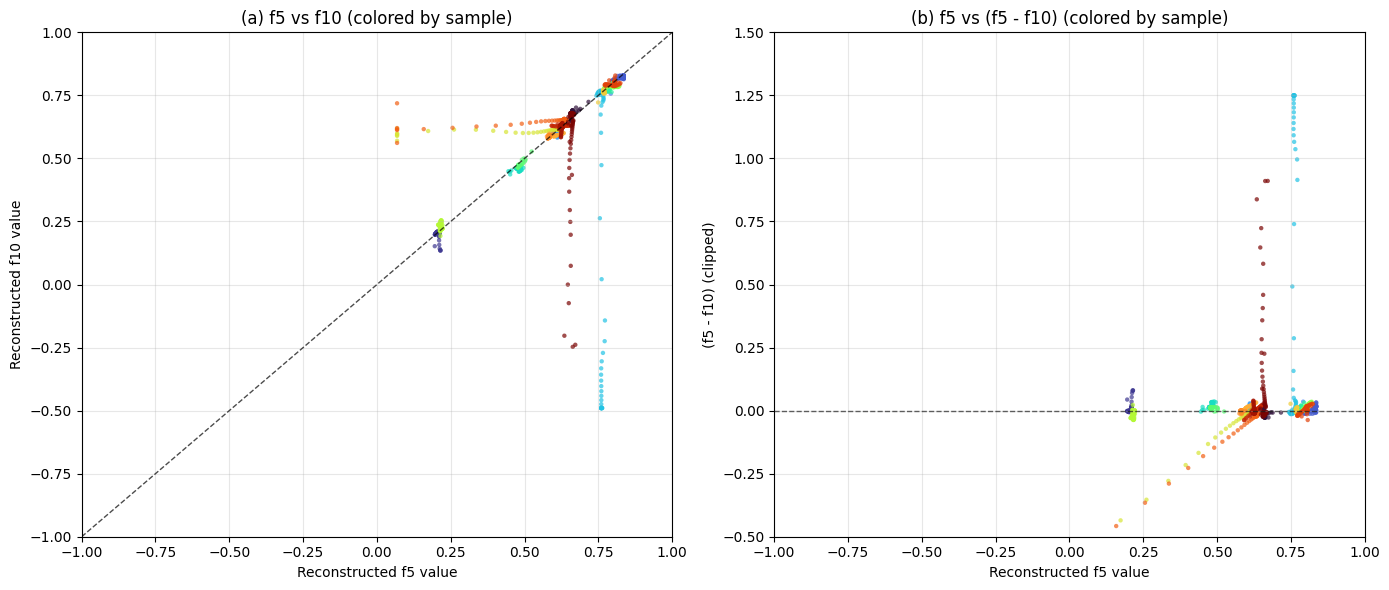

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1️⃣ CSV 불러오기
# =========================================================
csv_path = "vae_recon_uncovered_case0.csv"
df = pd.read_csv(csv_path)

# reconstruction 데이터만 선택
recon_cols = [c for c in df.columns if c.startswith("recon_")]
X_recon_flat = df[recon_cols].values
N_total, TF = X_recon_flat.shape
print(f"Loaded reconstruction matrix: {X_recon_flat.shape}")

# =========================================================
# 2️⃣ 원래 shape 복원 (예: T=50, F=12)
# =========================================================
F = 12
T = TF // F
X_recon = X_recon_flat.reshape(-1, T, F)
print(f"Reshaped to 3D tensor: {X_recon.shape}  (n, T, F)")

# =========================================================
# 3️⃣ 무작위 샘플 선택 (최대 500개)
# =========================================================
n_samples = min(20, X_recon.shape[0])
indices = np.random.choice(X_recon.shape[0], n_samples, replace=False)
print(f"Randomly selected {n_samples} samples from total {X_recon.shape[0]}")

# =========================================================
# 4️⃣ f5–f10 값 계산
# =========================================================
f5_vals = X_recon[indices, :, 4]
f10_vals = X_recon[indices, :, 9]
diff_vals = f5_vals - f10_vals  # 부호 포함

# ✳️ 클리핑
upper_clip_f5 = np.percentile(f5_vals, 99)
lower_clip_f5 = np.percentile(f5_vals, 1)
f5_vals_clipped = np.clip(f5_vals, lower_clip_f5, upper_clip_f5)

upper_clip_f10 = np.percentile(f10_vals, 99)
lower_clip_f10 = np.percentile(f10_vals, 1)
f10_vals_clipped = np.clip(f10_vals, lower_clip_f10, upper_clip_f10)

upper_clip_diff = np.percentile(diff_vals, 99)
lower_clip_diff = np.percentile(diff_vals, 1)
diff_vals_clipped = np.clip(diff_vals, lower_clip_diff, upper_clip_diff)

print(f"f5 range:  [{lower_clip_f5:.3f}, {upper_clip_f5:.3f}]")
print(f"f10 range: [{lower_clip_f10:.3f}, {upper_clip_f10:.3f}]")
print(f"diff range:[{lower_clip_diff:.3f}, {upper_clip_diff:.3f}]")

# =========================================================
# 5️⃣ 2개 subplot (좌: f5 vs f10 / 우: f5 vs (f5 - f10))
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 🎨 colormap — sample별로 색 다르게
cmap = plt.cm.get_cmap('turbo', n_samples)

# ---- (a) f5 vs f10 ----
for i in range(n_samples):
    axes[0].scatter(
        f5_vals_clipped[i, :], f10_vals_clipped[i, :],
        s=10, alpha=0.7, color=cmap(i), edgecolor='none'
    )
axes[0].plot([-1, 1], [-1, 1], 'k--', linewidth=1, alpha=0.7)
axes[0].set_xlim(-1, 1)
axes[0].set_ylim(-1, 1)
axes[0].set_xlabel("Reconstructed f5 value")
axes[0].set_ylabel("Reconstructed f10 value")
axes[0].set_title("(a) f5 vs f10 (colored by sample)")
axes[0].grid(alpha=0.3)

# ---- (b) f5 vs (f5 - f10) ----
for i in range(n_samples):
    axes[1].scatter(
        f5_vals_clipped[i, :], diff_vals_clipped[i, :],
        s=10, alpha=0.7, color=cmap(i), edgecolor='none'
    )
axes[1].axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(-0.5, 1.5)
axes[1].set_xlabel("Reconstructed f5 value")
axes[1].set_ylabel("(f5 - f10) (clipped)")
axes[1].set_title("(b) f5 vs (f5 - f10) (colored by sample)")
axes[1].grid(alpha=0.3)

# 🎨 Colorbar (공통)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n_samples))
# cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.04)
# cbar.set_label("Sample index", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


Loaded reconstruction matrix: (1229, 600)
Reshaped to 3D tensor: (1229, 50, 12)  (n, T, F)
Randomly selected 5 samples from total 1229


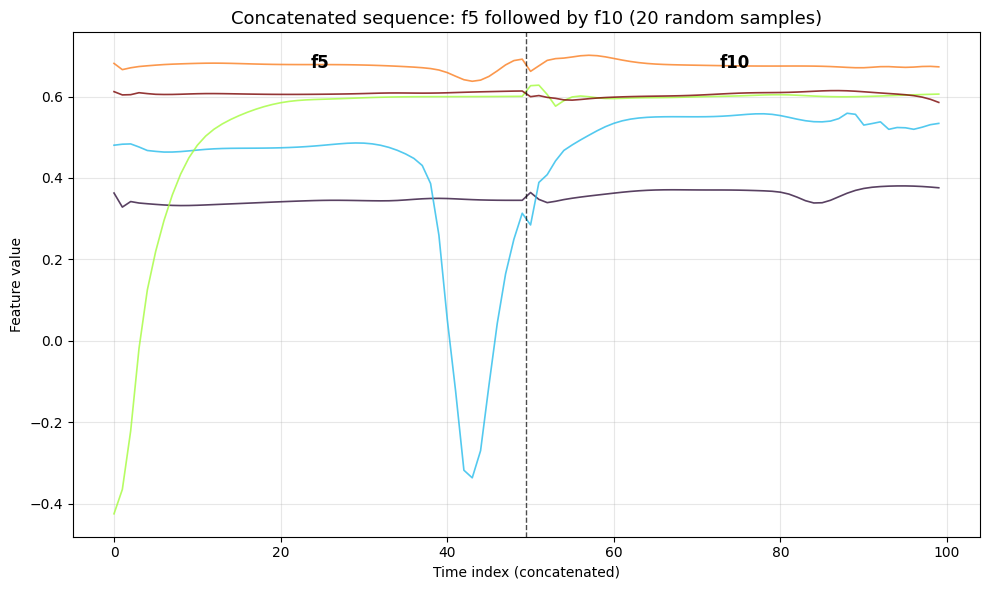

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1️⃣ CSV 불러오기
# =========================================================
csv_path = "vae_recon_uncovered_case0.csv"
df = pd.read_csv(csv_path)

# reconstruction 데이터만 선택
recon_cols = [c for c in df.columns if c.startswith("recon_")]
X_recon_flat = df[recon_cols].values
N_total, TF = X_recon_flat.shape
print(f"Loaded reconstruction matrix: {X_recon_flat.shape}")

# =========================================================
# 2️⃣ 원래 shape 복원 (예: T=50, F=12)
# =========================================================
F = 12
T = TF // F
X_recon = X_recon_flat.reshape(-1, T, F)
print(f"Reshaped to 3D tensor: {X_recon.shape}  (n, T, F)")

# =========================================================
# 3️⃣ 무작위 20개 샘플 선택
# =========================================================
n_samples = min(5, X_recon.shape[0])
indices = np.random.choice(X_recon.shape[0], n_samples, replace=False)
print(f"Randomly selected {n_samples} samples from total {X_recon.shape[0]}")

# =========================================================
# 4️⃣ f5, f10 추출 및 concat
# =========================================================
f5_vals = X_recon[indices, :, 4]    # [n_samples, T]
f10_vals = X_recon[indices, :, 9]   # [n_samples, T]

# 각 샘플마다 이어붙이기
concat_series = np.concatenate([f5_vals, f10_vals], axis=1)  # shape: [n_samples, 2T]
x_axis = np.arange(2 * T)

# 구간 경계선 위치 (f5→f10 구분)
boundary = T - 0.5

# =========================================================
# 5️⃣ 시각화
# =========================================================
plt.figure(figsize=(10, 6))
cmap = plt.cm.get_cmap('turbo', n_samples)

for i in range(n_samples):
    plt.plot(
        x_axis, concat_series[i, :],
        color=cmap(i),
        alpha=0.8,
        linewidth=1.2
    )

# 구분선 (f5 구간 / f10 구간)
plt.axvline(boundary, color='k', linestyle='--', linewidth=1, alpha=0.7)
plt.text(boundary/2, plt.ylim()[1]*0.9, "f5", ha='center', va='center', fontsize=12, fontweight='bold')
plt.text(boundary + T/2, plt.ylim()[1]*0.9, "f10", ha='center', va='center', fontsize=12, fontweight='bold')

plt.title("Concatenated sequence: f5 followed by f10 (20 random samples)", fontsize=13)
plt.xlabel("Time index (concatenated)")
plt.ylabel("Feature value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


✅ Total uncovered samples: 1229
🎯 Selected indices (>=50): [ 67  71  80  89 114]


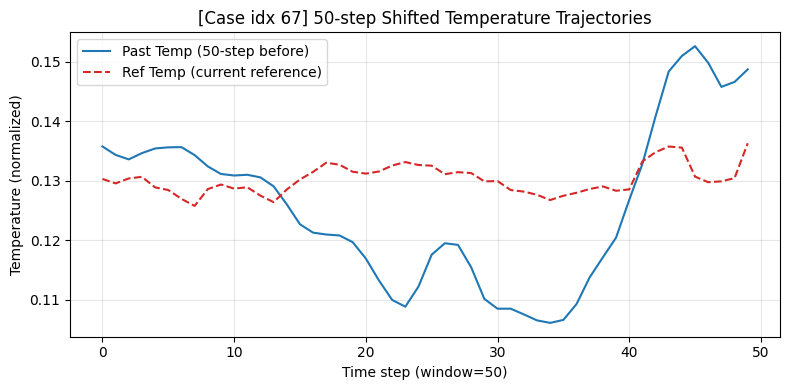

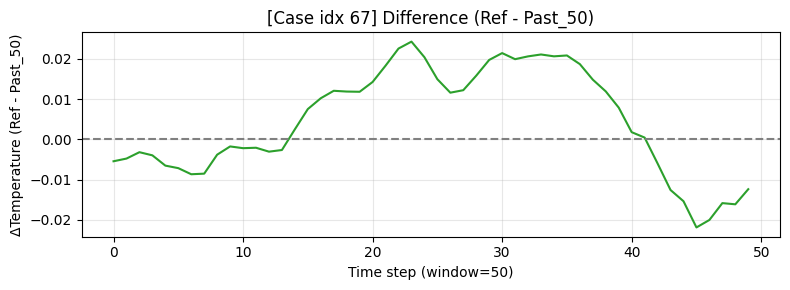

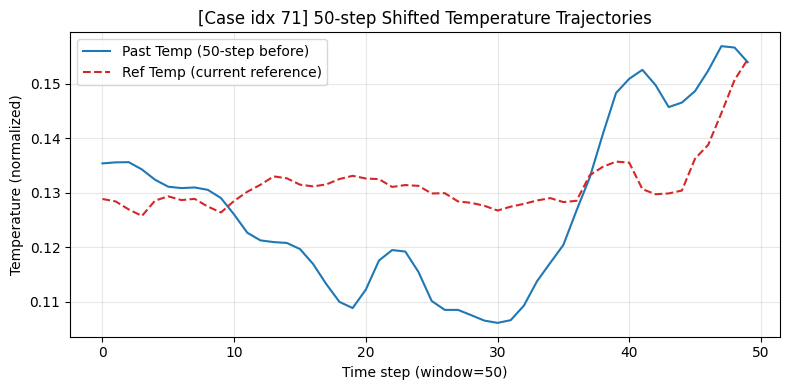

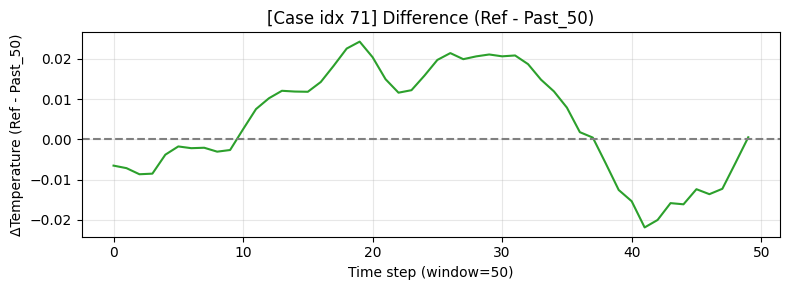

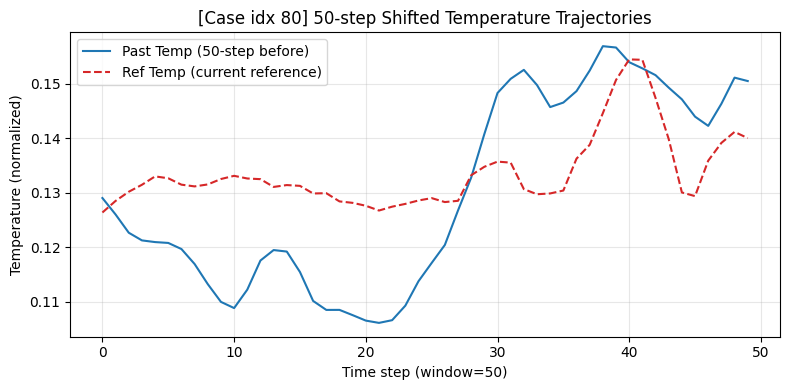

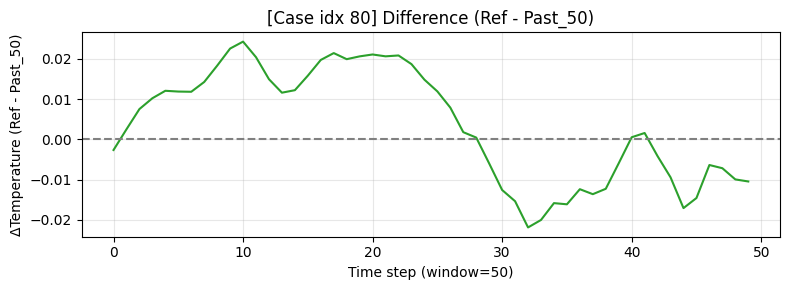

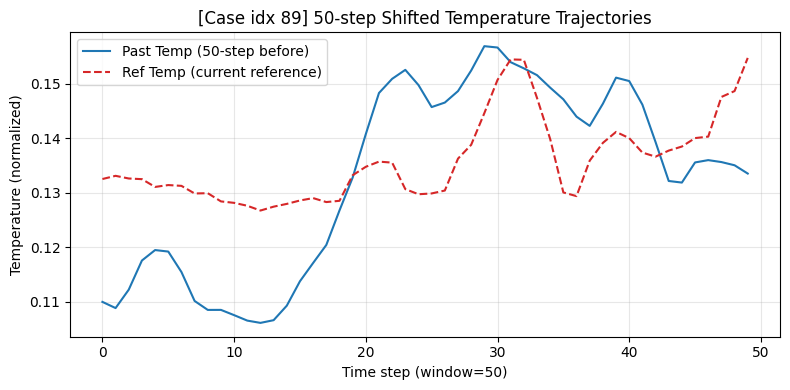

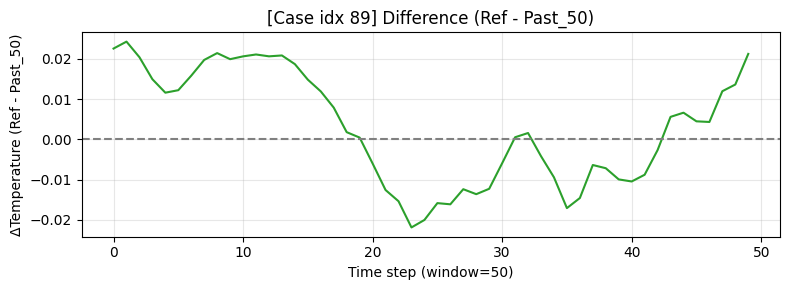

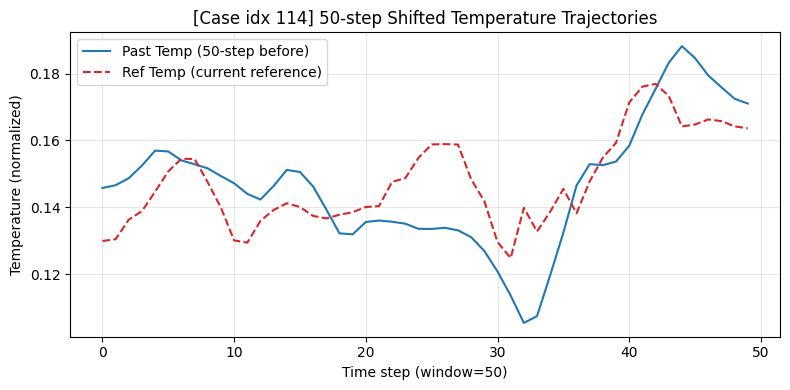

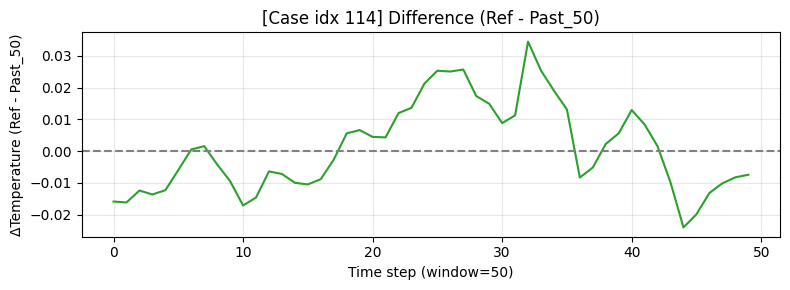

✅ 50-step aligned plots generated for 5 representative uncovered cases.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

# =========================================================
# 5️⃣ 시계열 비교 (past_temp_50step_before vs ref_temp)
# =========================================================

df_uncovered = pd.read_csv("vae_recon_uncovered_case0.csv")
idx_list = df_uncovered["case_index"].astype(int).unique()

# 50-step 전 구간이 존재하는 인덱스만 선택
valid_indices = idx_list[idx_list >= 50]
sample_indices = valid_indices[:5]

print(f"✅ Total uncovered samples: {len(idx_list)}")
print(f"🎯 Selected indices (>=50): {sample_indices}")

# X_case_all GPU → CPU 이동
X_case_all_cpu = X_case_all.cpu()

for idx in sample_indices:
    past_temp = X_case_all_cpu[idx, :, 4].numpy()
    ref_temp  = X_case_all_cpu[idx-50, :, 9].numpy()
    diff_temp = ref_temp - past_temp

    # ---- Plot 1 ----
    plt.figure(figsize=(8, 4))
    plt.plot(past_temp, label="Past Temp (50-step before)", color="tab:blue")
    plt.plot(ref_temp, label="Ref Temp (current reference)", color="tab:red", linestyle="--")
    plt.title(f"[Case idx {idx}] 50-step Shifted Temperature Trajectories")
    plt.xlabel("Time step (window=50)")
    plt.ylabel("Temperature (normalized)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2 ----
    plt.figure(figsize=(8, 3))
    plt.plot(diff_temp, color="tab:green")
    plt.axhline(0, color="gray", linestyle="--")
    plt.title(f"[Case idx {idx}] Difference (Ref - Past_50)")
    plt.xlabel("Time step (window=50)")
    plt.ylabel("ΔTemperature (Ref - Past_50)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✅ 50-step aligned plots generated for 5 representative uncovered cases.")


Total values: 58950 (n=1179, T=50)
Mean |Δ|: 0.2335, Std: 0.3420, Min/Max: [0.000, 1.783]


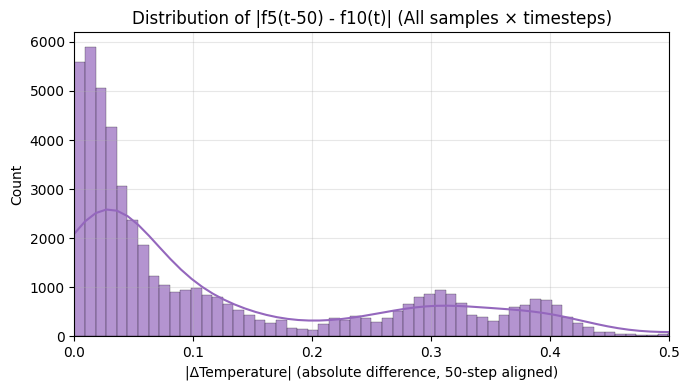

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 7️⃣ (Reconstructed) |f5(t-50) - f10(t)| 분포 보기 (temporal aligned)
# =========================================================

# 유효 인덱스 범위: 50-step offset을 적용할 수 있는 구간만
valid_idx = range(50, X_recon.shape[0])

# 모든 Δ값 수집
diff_sqrt_list = []
for i in valid_idx:
    past_f5 = X_recon[i, :, 4]   # 50-step 이전 f5
    ref_f10 = X_recon[i-50, :, 9]        # 현재 f10
    diff_sqrt_list.append(np.abs(ref_f10 - past_f5))  # = sqrt(diff^2)

# flatten
diff_sqrt = np.concatenate(diff_sqrt_list).flatten()

# 기본 통계
print(f"Total values: {diff_sqrt.size} (n={len(valid_idx)}, T={X_recon.shape[1]})")
print(f"Mean |Δ|: {diff_sqrt.mean():.4f}, Std: {diff_sqrt.std():.4f}, "
      f"Min/Max: [{diff_sqrt.min():.3f}, {diff_sqrt.max():.3f}]")

# --- 히스토그램 + KDE ---
plt.figure(figsize=(7,4))
sns.histplot(diff_sqrt, bins=200, kde=True, color="tab:purple", alpha=0.7)
plt.title("Distribution of |f5(t-50) - f10(t)| (All samples × timesteps)")
plt.xlabel("|ΔTemperature| (absolute difference, 50-step aligned)")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.xlim(0, 0.5)   # 필요 시 조정
plt.tight_layout()
plt.show()



Total points: 58950
Mean Temp (f5, 50-step before): 0.5234
Mean Signed Diff (f5-f10): 0.0300, Mean |Diff|: 0.2335
Range f5: [-1.011, 0.881]
Range Δ: [-1.783, 1.270]


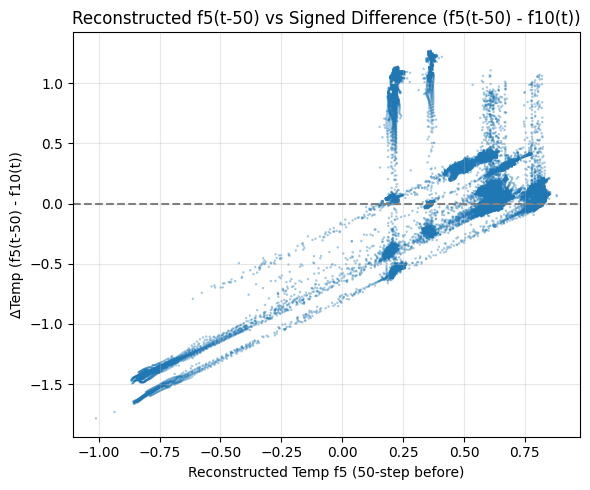

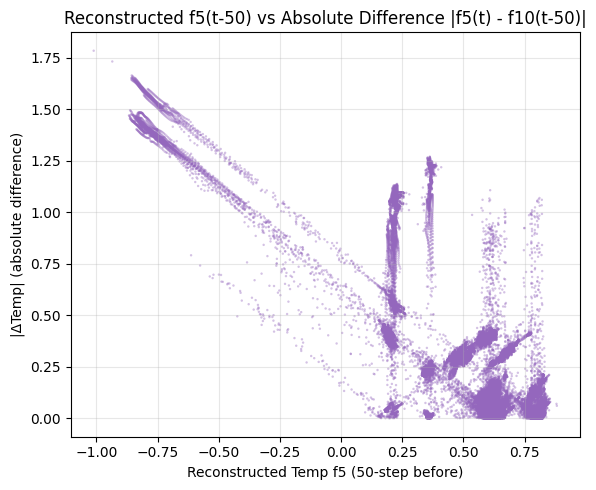

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 8️⃣ Reconstructed Temp vs Difference Scatter Plot (50-step aligned, No Clipping)
# =========================================================

# 유효 인덱스 (50-step 전 구간이 존재해야 함)
valid_idx = range(50, X_recon.shape[0])

# (1) 각 i에 대해 f5(t-50) vs f10(t)
f5_shifted, f10_current = [], []
for i in valid_idx:
    f5_shifted.append(X_recon[i, :, 4])  # 50-step 이전 f5
    f10_current.append(X_recon[i-50, :, 9])      # 현재 f10

f5_all = np.concatenate(f5_shifted).flatten()
f10_all = np.concatenate(f10_current).flatten()

# (2) 차이 계산
diff_signed = f5_all - f10_all
diff_abs = np.abs(diff_signed)

print(f"Total points: {len(f5_all)}")
print(f"Mean Temp (f5, 50-step before): {f5_all.mean():.4f}")
print(f"Mean Signed Diff (f5-f10): {diff_signed.mean():.4f}, Mean |Diff|: {diff_abs.mean():.4f}")
print(f"Range f5: [{f5_all.min():.3f}, {f5_all.max():.3f}]")
print(f"Range Δ: [{diff_signed.min():.3f}, {diff_signed.max():.3f}]")

# =========================================================
# (a) f5(t-50) vs (f5(t-50) - f10(t)) (부호 포함)
# =========================================================
plt.figure(figsize=(6,5))
plt.scatter(f5_all, diff_signed, s=3, alpha=0.4, color="tab:blue", edgecolor="none")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Reconstructed f5(t-50) vs Signed Difference (f5(t-50) - f10(t))")
plt.xlabel("Reconstructed Temp f5 (50-step before)")
plt.ylabel("ΔTemp (f5(t-50) - f10(t))")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# (b) f5(t-50) vs |f5(t-50) - f10(t)| (절대 차이)
# =========================================================
plt.figure(figsize=(6,5))
plt.scatter(f5_all, diff_abs, s=3, alpha=0.4, color="tab:purple", edgecolor="none")
plt.title("Reconstructed f5(t-50) vs Absolute Difference |f5(t) - f10(t-50)|")
plt.xlabel("Reconstructed Temp f5 (50-step before)")
plt.ylabel("|ΔTemp| (absolute difference)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
